In [6]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Outlier Detection

In this script we will apply different dimensionality reduction techniques again to the SOAP feature matrix and visualize the results. At this point we generate the following test data:

We generate 100 structures for each of our five clusters with small pertubations of 0.01 and then introduce 800 random structures as outliers. We then see how we can seperate the outliers from the orignal data using different techniques

In [7]:
# SOAP feature config
from dscribe.descriptors import SOAP
r_cut = 6
n_max = 12
l_max = 8
sigma = 0.5
rbf = "gto"
average = "inner"

h2o_2_1 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_1.xyz")
h2o_2_2 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_2.xyz")
h2o_2_3 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_3.xyz")
h2o_2_4 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_4.xyz")
h2o_2_5 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_5.xyz")

# Find covalent bonds using a simple distance-based criterion
def find_bonds(atoms, cutoff=1.2):
    positions = atoms.get_positions()
    symbols = atoms.get_chemical_symbols()
    bonds = []
    for i in range(len(atoms)):
        for j in range(i + 1, len(atoms)):
            distance = np.linalg.norm(positions[i] - positions[j])
            if distance < cutoff:
                bonds.append((i, j))
    return bonds

print(find_bonds(h2o_2_1))
print(find_bonds(h2o_2_2))
print(find_bonds(h2o_2_3))
print(find_bonds(h2o_2_4))
print(find_bonds(h2o_2_5))

submol_indices_1 = [[0,1,2], [3,4,5]]
submol_indices_2 = [[0,2,3],[1,4,5]]
submol_indices_3 = [[0,2,3],[1,4,5]]
submol_indices_4 = [[0,2,3],[1,4,5]]
submol_indices_5 = [[0,2,3],[1,4,5]]

soap = SOAP(
    species=["H", "O"],
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf=rbf,
    average=average,
)

def generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=0.05):
    perturbed_structures = []
    perturbed_labels = []

    for struct_idx, (original_struct, submol_idx, label) in enumerate(zip(original_structures, submol_indices, structure_labels)):
        for pert in range(n_perturbations):
            # Create a copy of the structure
            perturbed_struct = original_struct.copy()
            
            # Randomly choose which submolecule to perturb
            submol_to_perturb = np.random.choice([0, 1])
            indices_to_perturb = submol_idx[submol_to_perturb]
            
            # Generate random perturbations
            positions = perturbed_struct.get_positions()
            # Sample random vector from normal distribution and apply the perturbation scale
            random_displacement = np.random.randn(len(indices_to_perturb), 3) * perturbation_scale
            
            # Apply perturbations to selected submolecule
            # This preserves the internal structure of the submolecule while introducing noise to the overall structure
            for i, atom_idx in enumerate(indices_to_perturb):
                positions[atom_idx] += random_displacement[i]
            
            perturbed_struct.set_positions(positions)
            perturbed_structures.append(perturbed_struct)
            perturbed_labels.append(label)

    # Generate SOAP features for all perturbed structures
    perturbed_feature_matrix = soap.create(perturbed_structures)
    
    return perturbed_structures, perturbed_labels, perturbed_feature_matrix

def generate_outliers(original_structures, n_outliers=100, displacement=0.1):
    outlier_structures = []
    outlier_labels = []
    for struct_idx, original_struct in enumerate(original_structures):
        for _ in range(n_outliers // len(original_structures)):
            outlier_struct = original_struct.copy()
            positions = outlier_struct.get_positions()
            random_displacement = np.random.randn(*positions.shape) * displacement
            positions += random_displacement
            outlier_struct.set_positions(positions)
            outlier_structures.append(outlier_struct)
            # Make all into one outlier class
            outlier_labels.append("Outlier")
    return outlier_structures, outlier_labels

[(0, 1), (0, 2), (3, 4), (3, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]


In [8]:
original_structures = [h2o_2_1, h2o_2_2, h2o_2_3, h2o_2_4, h2o_2_5]
structure_labels = ["(H$_2$O)$_2$-1", "(H$_2$O)$_2$-2", "(H$_2$O)$_2$-3", "(H$_2$O)$_2$-4", "(H$_2$O)$_2$-5"]
submol_indices = [submol_indices_1, submol_indices_2, submol_indices_3, submol_indices_4, submol_indices_5]
perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=100, perturbation_scale=0.01)
outlier_structures, outlier_labels = generate_outliers(original_structures, n_outliers=800, displacement=0.1)
all_structures = perturbed_structures + outlier_structures
all_labels = perturbed_labels + outlier_labels
all_feature_matrix = np.vstack([perturbed_feature_matrix, soap.create(outlier_structures)])

Original feature matrix shape: (1300, 2700)
Reduced feature matrix shape: (1300, 5)


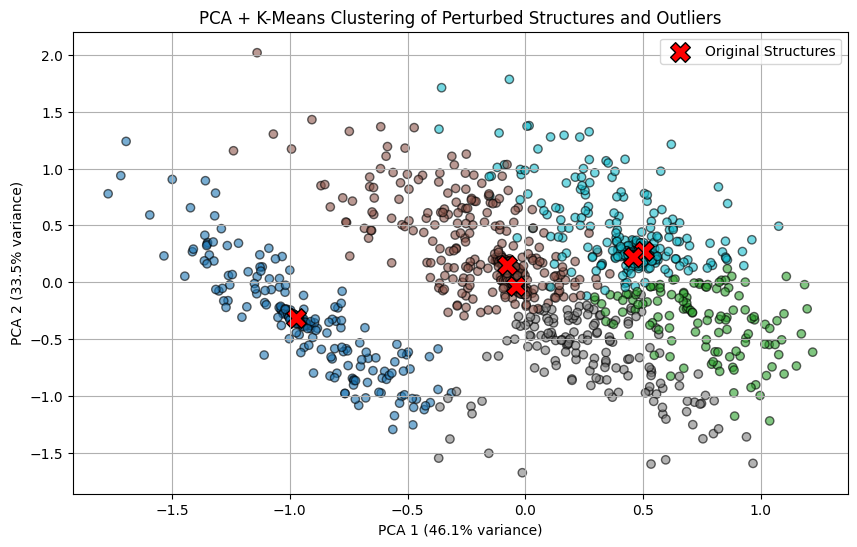

In [9]:
# RUN PCA on the feature matrix to retain 95 % of variance run K-Means with 5 clusters and visualize the results in a 2D plot
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# PCA to retain 95% of variance
pca = PCA(n_components=0.95)
reduced_features = pca.fit_transform(all_feature_matrix)
print(f"Original feature matrix shape: {all_feature_matrix.shape}")
print(f"Reduced feature matrix shape: {reduced_features.shape}")

# Run K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(reduced_features)
# Visualize the results in a 2D plot
cmap = plt.get_cmap("tab10", np.unique(cluster_labels).size)




plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=cluster_labels, cmap=cmap, alpha=0.6, edgecolors='k')
# Compute embedding of original structures and scatter
original_features = soap.create(original_structures)
original_reduced = pca.transform(original_features)
plt.scatter(original_reduced[:, 0], original_reduced[:, 1], c='red', marker='X', s=200, label='Original Structures', edgecolors='k')
plt.legend()
plt.title("PCA + K-Means Clustering of Perturbed Structures and Outliers")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid()
plt.show()


We can see that tough the K-Means is able to somewhat capture the clusters in the data there is lot of noise which makes clustering difficult and is also bad for out embedding

## Z-Score --> Global Cleanup

We can first use the C-Score to remove global outliers we use the threshold of 3

Original feature matrix shape: (1300, 2700)
Cleaned feature matrix shape: (672, 2700)
Number of outliers removed: 628


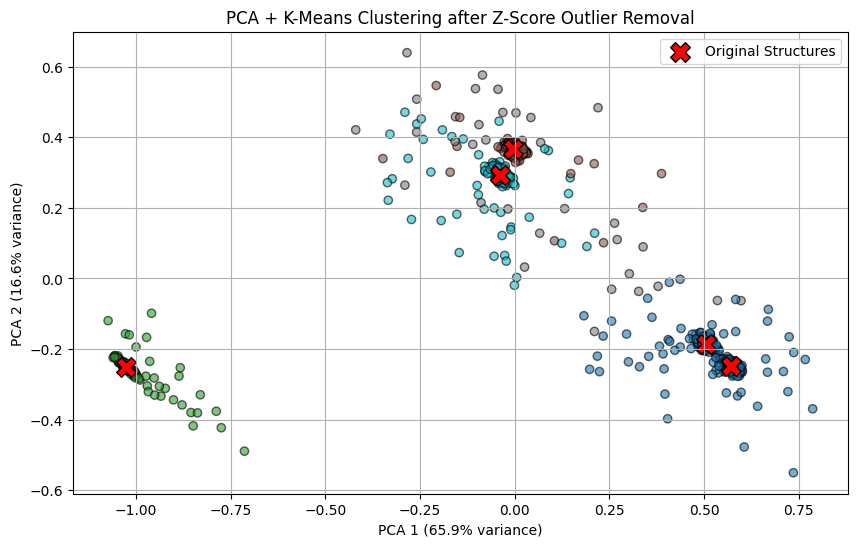

In [11]:
# Clean up with Z-Score
from scipy.stats import zscore
# Apply Z-Score normalization to the feature matrix to remove global outliers
z_scores = zscore(all_feature_matrix, axis=0)
# Identify outliers based on Z-Score threshold (e.g., 3)
outlier_mask = np.any(np.abs(z_scores) > 3, axis=1)
# Filter out outliers from the feature matrix and labels
cleaned_feature_matrix = all_feature_matrix[~outlier_mask]
cleaned_labels = np.array(all_labels)[~outlier_mask]
print(f"Original feature matrix shape: {all_feature_matrix.shape}")
print(f"Cleaned feature matrix shape: {cleaned_feature_matrix.shape}")
print(f"Number of outliers removed: {np.sum(outlier_mask)}")
# Run PCA and K-Means again on the cleaned data
pca_cleaned = PCA(n_components=0.95)
reduced_cleaned = pca_cleaned.fit_transform(cleaned_feature_matrix)
kmeans_cleaned = KMeans(n_clusters=5, random_state=42)
cluster_labels_cleaned = kmeans_cleaned.fit_predict(reduced_cleaned)
# Visualize the cleaned results in a 2D plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_cleaned[:, 0], reduced_cleaned[:, 1], c=cluster_labels_cleaned, cmap=cmap, alpha=0.6, edgecolors='k')
# Compute embedding of original structures and scatter
original_features = soap.create(original_structures)
original_reduced = pca_cleaned.transform(original_features)
plt.scatter(original_reduced[:, 0], original_reduced[:, 1], c='red', marker='X', s=200, label='Original Structures', edgecolors='k')
plt.legend()
plt.title("PCA + K-Means Clustering after Z-Score Outlier Removal")
plt.xlabel(f"PCA 1 ({pca_cleaned.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca_cleaned.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid()
plt.show()

Already this Z-Score filtering is able to remove a lot of the outliers in the data and highly improve our results of the clustering and embedding.

## Isolation forest

Isolation forest is an unsupervised learning algorithm for anomaly detection that works on the principle of isolating anomalies rather than profiling normal data points. It constructs an ensemble of isolation trees, where each tree is built by randomly selecting a feature and then randomly selecting a split value for that feature. The idea is that anomalies are more likely to be isolated in fewer splits compared to normal data points, which require more splits to be isolated.

Number of outliers detected by Isolation Forest: 520
Feature matrix shape after Isolation Forest cleaning: (780, 2700)


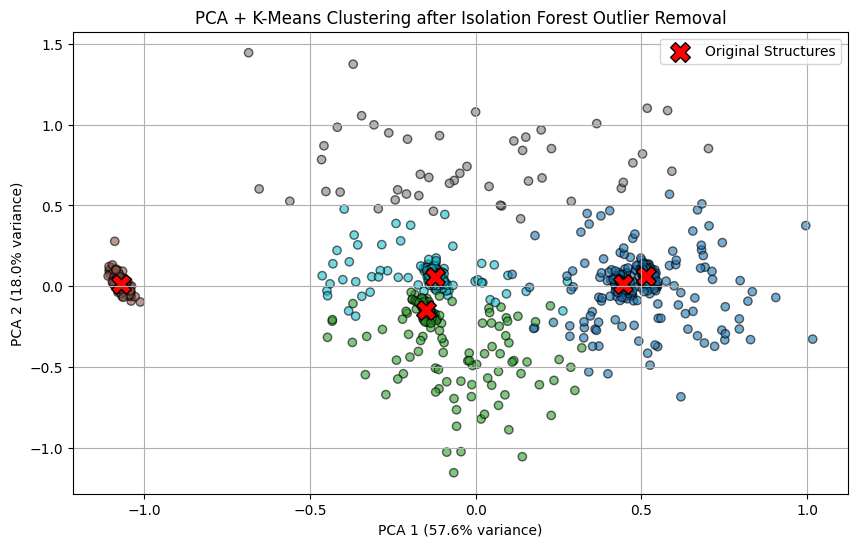

In [16]:
# Run Isolation Forest for outlier detection
from sklearn.ensemble import IsolationForest
# for this we need a good guess of the contamination in our data
isolation_forest = IsolationForest(contamination=0.4, random_state=42)
isolation_labels = isolation_forest.fit_predict(all_feature_matrix)
# Isolation Forest labels outliers as -1 and inliers as 1
isolation_outliers = isolation_labels == -1
print(f"Number of outliers detected by Isolation Forest: {np.sum(isolation_outliers)}")
# Filter out outliers based on Isolation Forest results
cleaned_feature_matrix_if = all_feature_matrix[~isolation_outliers]
cleaned_labels_if = np.array(all_labels)[~isolation_outliers]
print(f"Feature matrix shape after Isolation Forest cleaning: {cleaned_feature_matrix_if.shape}")
# Run PCA and K-Means again on the Isolation Forest cleaned data
pca_if = PCA(n_components=0.95)
reduced_if = pca_if.fit_transform(cleaned_feature_matrix_if)
kmeans_if = KMeans(n_clusters=5, random_state=42)
cluster_labels_if = kmeans_if.fit_predict(reduced_if)
# Visualize the Isolation Forest cleaned results in a 2D plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_if[:, 0], reduced_if[:, 1], c=cluster_labels_if, cmap=cmap, alpha=0.6, edgecolors='k')
# Compute embedding of original structures and scatter
original_features = soap.create(original_structures)
original_reduced_if = pca_if.transform(original_features)
plt.scatter(original_reduced_if[:, 0], original_reduced_if[:, 1], c='red', marker='X', s=200, label='Original Structures', edgecolors='k')
plt.legend()
plt.title("PCA + K-Means Clustering after Isolation Forest Outlier Removal")
plt.xlabel(f"PCA 1 ({pca_if.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca_if.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid()
plt.show()


This also works quite well and is able to remove a lot of outliers from the data and significantly improve our results. 

Feature matrix shape after combined Z-Score and Isolation Forest cleaning: (537, 2700)


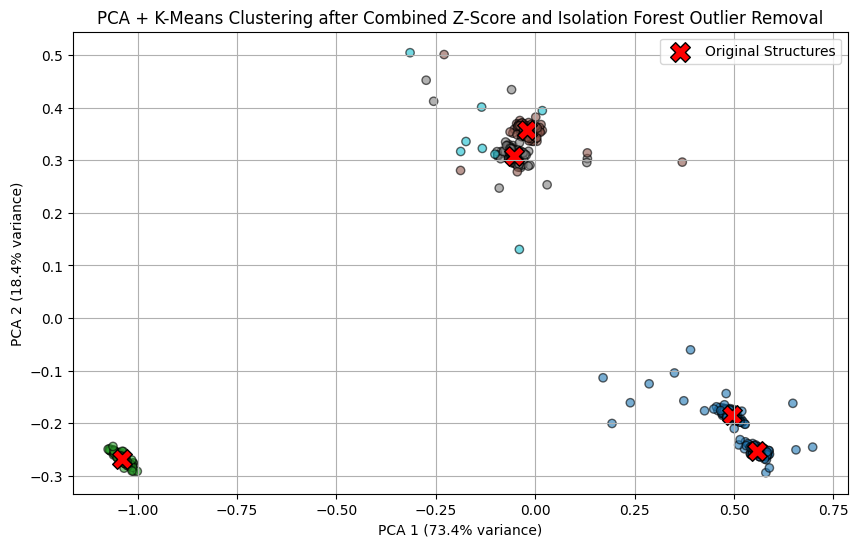

In [17]:
# We now combine Z-Score filtering and isolation forest to look out our results
# First apply Z-Score filtering
z_scores = zscore(all_feature_matrix, axis=0)
outlier_mask_z = np.any(np.abs(z_scores) > 3, axis=1)
cleaned_feature_matrix_z = all_feature_matrix[~outlier_mask_z]
cleaned_labels_z = np.array(all_labels)[~outlier_mask_z]
# Then apply Isolation Forest on the Z-Score cleaned data
isolation_forest_combined = IsolationForest(contamination=0.2, random_state=42)
isolation_labels_combined = isolation_forest_combined.fit_predict(cleaned_feature_matrix_z)
isolation_outliers_combined = isolation_labels_combined == -1
cleaned_feature_matrix_combined = cleaned_feature_matrix_z[~isolation_outliers_combined]
cleaned_labels_combined = cleaned_labels_z[~isolation_outliers_combined]
print(f"Feature matrix shape after combined Z-Score and Isolation Forest cleaning: {cleaned_feature_matrix_combined.shape}")
# Run PCA and K-Means on the combined cleaned data
pca_combined = PCA(n_components=0.95)
reduced_combined = pca_combined.fit_transform(cleaned_feature_matrix_combined)
kmeans_combined = KMeans(n_clusters=5, random_state=42)
cluster_labels_combined = kmeans_combined.fit_predict(reduced_combined)
# Visualize the combined cleaned results in a 2D plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_combined[:, 0], reduced_combined[:, 1], c=cluster_labels_combined, cmap=cmap, alpha=0.6, edgecolors='k')
# Compute embedding of original structures and scatter
original_features = soap.create(original_structures)
original_reduced_combined = pca_combined.transform(original_features)
plt.scatter(original_reduced_combined[:, 0], original_reduced_combined[:, 1], c='red', marker='X', s=200, label='Original Structures', edgecolors='k')
plt.legend()
plt.title("PCA + K-Means Clustering after Combined Z-Score and Isolation Forest Outlier Removal")
plt.xlabel(f"PCA 1 ({pca_combined.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca_combined.explained_variance_ratio_[1]*100:.1f}% variance)")    
plt.grid()
plt.show()

The combination of this two techniques is able to remove most of the outliers from the data and significantly improve our results. One can now clearly see the clusters even in this PCA representation. Another last step would be for example to use a local outlier factor which compares the local density of a point to the local densities of its neighbors to further clean up the data. But for now we will stop here and use this cleaned data for our embedding and clustering.

Feature matrix shape after Local Outlier Factor cleaning: (483, 2700)


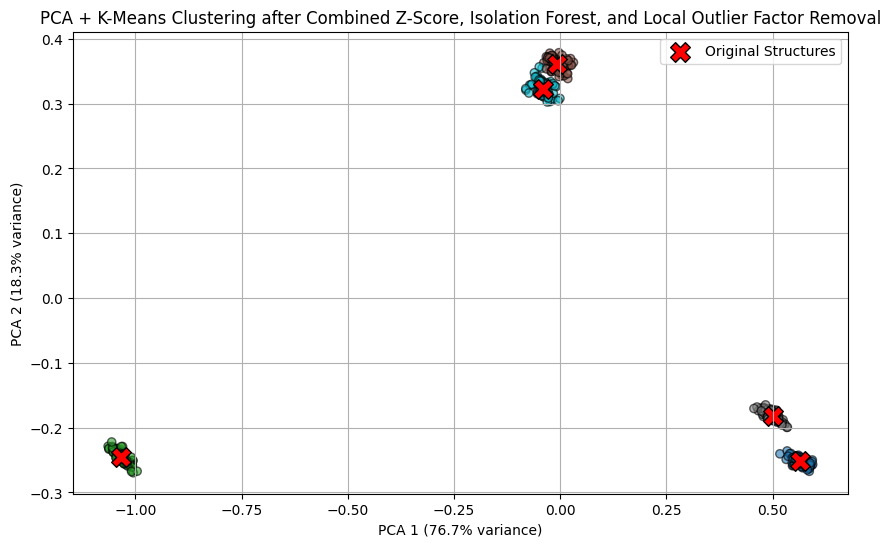

In [18]:
from sklearn.neighbors import LocalOutlierFactor
# Apply Local Outlier Factor on the combined cleaned data
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof_labels = lof.fit_predict(cleaned_feature_matrix_combined)
lof_outliers = lof_labels == -1
cleaned_feature_matrix_final = cleaned_feature_matrix_combined[~lof_outliers]
cleaned_labels_final = cleaned_labels_combined[~lof_outliers]
print(f"Feature matrix shape after Local Outlier Factor cleaning: {cleaned_feature_matrix_final.shape}")
# Run PCA and K-Means on the final cleaned data
pca_final = PCA(n_components=0.95)
reduced_final = pca_final.fit_transform(cleaned_feature_matrix_final)
kmeans_final = KMeans(n_clusters=5, random_state=42)
cluster_labels_final = kmeans_final.fit_predict(reduced_final)
# Visualize the final cleaned results in a 2D plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_final[:, 0], reduced_final[:, 1], c=cluster_labels_final, cmap=cmap, alpha=0.6, edgecolors='k')
# Compute embedding of original structures and scatter
original_features = soap.create(original_structures)
original_reduced_final = pca_final.transform(original_features)
plt.scatter(original_reduced_final[:, 0], original_reduced_final[:, 1], c='red', marker='X', s=200, label='Original Structures', edgecolors='k')
plt.legend()
plt.title("PCA + K-Means Clustering after Combined Z-Score, Isolation Forest, and Local Outlier Factor Removal")
plt.xlabel(f"PCA 1 ({pca_final.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca_final.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid()
plt.show()